# 2) Analyze source collection and target file

This notebook includes the code to analyze the collection of sounds compiled in the previous notebook and that will be later used as the source collection in our audio mosaicing code. The notebook also contains the code to analyze the target audio file that will be later reconstructed using sound chunks from the source collection.

The audio analysis carried out in this notebook uses the Pythonn bindings of the Essentia library which was introduced in the first session of AMPLAB. Please make sure you checked the [Essentia Python tutorial](https://essentia.upf.edu/documentation/essentia_python_tutorial.html) to get familiarized with using Essentia in Python. Also useful is to always have a browser tab opened with Essentia's [Algorithms Reference](https://essentia.upf.edu/documentation/algorithms_reference.html) documentation page.

In [5]:
# Essentia
%pip install essentia
# Freesound-python
#!pip install git+https://github.com/mtg/freesound-python.git
# Mount drive and cd to notebook folder
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# Replace with your path
%cd '/Users/martinsssssss/Desktop/SMC/ACTSM/Block II/1. Sound Retrieval with Fresound/audio-mosaicing'

/Users/martinsssssss/Desktop/SMC/ACTSM/Block II/1. Sound Retrieval with Fresound/audio-mosaicing


/Users/martinsssssss/opt/anaconda3/envs/audio-mosaicing/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
import pandas as pd
import essentia
import essentia.standard as estd
import matplotlib.pyplot as plt
from IPython.display import display, Audio

In [7]:
# Define here our sound analysis function
# NOTE: remember that if you update this function and want to run a new analysis you'll need to re-run both
# this cell and the cells below that carry out the audio analysis and that call the analysis function.
# After analyzing the source collection or the target file, make sure to correct descriptors have been
# extracted by checking the DataFrame contents. DataFrame contents can be printed on screen as a table
# using 'display(data_frame_object)'

def analyze_sound(audio_path, frame_size=None, audio_id=None, sync_with_beats=False):
    """Analyze the audio file given in 'sound_path'.
    Use the parameter 'frame_size' to set the size of the chunks in which the audio will
    be split for analysis. If no frame_size is given, the whole audio will be analyzed as
    a single frame.
    Use the 'audio_id' parameter to pass a custom identifier for the audio that will be
    included in the analysis results. This can be useful to later identify to which file an analysis belongs.
    """
    analysis_output = []  # Here we'll store the analysis results for each chunk (frame) of the audio file

    # Load audio file
    loader = estd.MonoLoader(filename=audio_path)
    audio = loader()

    # Some processing of frame_size parameter to avoid later problems
    if frame_size is None:
        frame_size = len(audio)  # If no frame_size is given use no frames (analyze all audio at once)
    if frame_size % 2 != 0:
        frame_size = frame_size + 1 # Make frame size even

    # Calculate the start and end samples for each equally-spaced audio frame
    if sync_with_beats:
      beat_tracker_algo = estd.BeatTrackerDegara()
      beat_positions = beat_tracker_algo(audio)
      beat_positions = [int(round(position * 44100)) for position in beat_positions]
      frame_start_end_samples = zip(beat_positions[:-1], beat_positions[1:])
    else:
      frame_start_samples = range(0, len(audio), frame_size)
      frame_start_end_samples = zip(frame_start_samples[:-1], frame_start_samples[1:])

    # Iterate over audio frames and analyze each one
    for count, (fstart, fend) in enumerate(frame_start_end_samples):

        # Get corresponding audio chunk and initialize dictionary to sotre analysis results with some basic metadata
        frame = audio[fstart:fend]
        frame_output = {
            'freesound_id': audio_id,
            'id': '{0}_f{1}'.format(audio_id, count),
            'path': audio_path,
            'start_sample': fstart,
            'end_sample': fend,
        }

        # Extract loudness
        loudness_algo = estd.Loudness()
        loudness = loudness_algo(frame)
        frame_output['loudness'] = loudness / len(frame)  # Normnalize by length of frame

        # Extract MFCC coefficients
        w_algo = estd.Windowing(type = 'hann')
        spectrum_algo = estd.Spectrum()
        mfcc_algo = estd.MFCC()
        spec = spectrum_algo(w_algo(frame))
        _, mfcc_coeffs = mfcc_algo(spec)
        frame_output.update({'mfcc_{0}'.format(j): mfcc_coeffs[j] for j in range(0, len(mfcc_coeffs))})

        # Extract other features here and add to 'frame_output' dictionary
        # ...

        # Add frame analysis results to output
        analysis_output.append(frame_output)

    return analysis_output


## Analyze source collection

In [8]:
DATAFRAME_FILENAME = 'dataframe.csv'  # DataFrame file of the sound source collection to analyze
DATAFRAME_SOURCE_FILENAME = 'dataframe_source.csv'  # DataFrame file where to store the results of our analysis

# Load the DataFrame of the sound source collection created in previous notebook and analyze all sound files in it
df = pd.read_csv(open(DATAFRAME_FILENAME), index_col=0)
analyses = []
for i in range(0, len(df)):
    sound = df.iloc[i]  # Get DataFrame sound at position 'i'
    print('Analyzing sound with id {0} [{1}/{2}]'.format(sound['freesound_id'], i + 1, len(df)))
    try:
      analysis_output = analyze_sound(sound['path'], frame_size=8192, audio_id=sound['freesound_id'])  # Split audio in chunks of 8192 samples (~185ms)
      analyses += analysis_output
    except RuntimeError:
      continue

# Store analysis results in a new Pandas DataFrame and save it
df_source = pd.DataFrame(analyses)
df_source.to_csv(DATAFRAME_SOURCE_FILENAME)
print('Saved source DataFrame with {0} entries! {1}'.format(len(df_source), DATAFRAME_SOURCE_FILENAME))

display(df_source)  # Show DataFrane contents
df_source.describe()  # Show some statistics of numerical fields in the DataFrame

Analyzing sound with id 132584 [1/63]
Analyzing sound with id 673512 [2/63]
Analyzing sound with id 647617 [3/63]
Analyzing sound with id 400707 [4/63]
Analyzing sound with id 581461 [5/63]
Analyzing sound with id 25634 [6/63]
Analyzing sound with id 465547 [7/63]
Analyzing sound with id 431636 [8/63]
Analyzing sound with id 599886 [9/63]
Analyzing sound with id 564190 [10/63]
Analyzing sound with id 58481 [11/63]
Analyzing sound with id 98259 [12/63]
Analyzing sound with id 16290 [13/63]
Analyzing sound with id 509486 [14/63]
Analyzing sound with id 323619 [15/63]
Analyzing sound with id 366400 [16/63]
Analyzing sound with id 196758 [17/63]
Analyzing sound with id 278173 [18/63]
Analyzing sound with id 78567 [19/63]
Analyzing sound with id 67407 [20/63]
Analyzing sound with id 337873 [21/63]
Analyzing sound with id 201094 [22/63]
Analyzing sound with id 433742 [23/63]
Analyzing sound with id 209942 [24/63]
Analyzing sound with id 638643 [25/63]
Analyzing sound with id 457041 [26/63]
A

,freesound_id,id,path,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
0,132584,132584_f0,files/132584_2409787-hq.ogg,0,8192,0.016301,-1144.316284,162.570221,140.591125,109.819305,77.023384,48.437050,28.031143,16.743053,12.827419,13.055492,14.188225,14.120167,12.311432
1,132584,132584_f1,files/132584_2409787-hq.ogg,8192,16384,0.001751,-1229.118896,50.385822,49.694302,48.562408,47.019936,45.107597,42.874077,40.375652,37.672882,34.829105,31.907753,28.970448,26.074848
2,132584,132584_f2,files/132584_2409787-hq.ogg,16384,24576,0.000037,-1249.117798,22.292068,22.161190,21.944672,21.644341,21.263557,20.805664,20.275433,19.677914,19.018871,18.304573,17.541729,16.737419
3,673512,673512_f0,files/673512_3130497-hq.ogg,0,8192,0.013325,-1120.314697,186.085968,139.704285,85.860107,43.722450,21.222084,14.597702,15.201031,16.477917,16.258755,14.979012,13.366108,11.740959
4,673512,673512_f1,files/673512_3130497-hq.ogg,8192,16384,0.003466,-1230.337769,48.668720,47.998318,46.905472,45.425331,43.605324,41.501793,39.178524,36.703033,34.143925,31.567818,29.036732,26.605610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,517297,517297_f0,files/517297_10137963-hq.ogg,0,8192,0.000585,-831.260742,-26.467384,-87.893936,-46.373775,-51.170891,-10.259689,-14.577358,-2.904037,-6.054874,1.321733,-1.987133,2.861959,2.825012
394,5567,5567_f0,files/5567_2518-hq.ogg,0,8192,0.006013,-550.890442,32.131180,0.189981,4.844004,-1.808872,0.343670,-1.088823,2.926310,2.870220,0.985872,-0.216423,-0.366072,3.086082
395,5567,5567_f1,files/5567_2518-hq.ogg,8192,16384,0.015464,-443.313477,26.310579,1.501711,4.935081,2.688988,2.371135,-1.484260,-3.603107,-4.588249,-4.112026,-6.519199,-5.810934,-5.540646
396,5567,5567_f2,files/5567_2518-hq.ogg,16384,24576,0.001700,-687.894165,35.514923,0.763330,2.652151,-4.482679,-2.702824,-4.096386,-2.264961,-4.734259,-3.234825,0.126881,1.140327,4.446611


,freesound_id,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,419159.371859,36246.512563,44438.512563,0.004722,-913.455261,123.766449,11.244101,26.430286,8.134033,11.349345,7.798620,7.335505,1.782684,5.290597,2.952348,1.359130,0.606468
std,207232.762729,30836.506320,30836.506320,0.005857,242.698685,96.572533,61.493423,33.808529,28.883043,23.953775,19.784914,15.422311,14.896009,12.758981,10.923120,11.518445,11.354778
min,5567.000000,0.000000,8192.000000,0.000000,-1264.911621,-245.757843,-125.922546,-59.867115,-69.059013,-62.558998,-55.113319,-42.538059,-94.744263,-33.517574,-35.664150,-46.893871,-44.473663
25%,337873.000000,8192.000000,16384.000000,0.000227,-1135.455750,50.278777,-34.902966,0.000031,-14.199112,-4.464328,-6.530704,-1.455057,-5.950049,-1.195074,-2.478104,-2.578328,-4.057411
50%,431944.000000,32768.000000,40960.000000,0.001921,-908.817047,134.063530,6.538850,24.231235,5.701778,10.678848,4.976280,4.841992,1.097935,3.768934,2.726624,1.733977,-0.000042
75%,578558.250000,57344.000000,65536.000000,0.007999,-710.126373,208.111618,44.718342,51.660691,28.474529,29.297844,20.086079,16.126388,10.468751,12.389872,9.698348,7.103141,5.507969
max,827848.000000,122880.000000,131072.000000,0.038969,-443.313477,320.520935,178.630081,122.146423,90.588051,75.181412,72.671188,58.895229,41.210220,89.650375,32.707108,32.816681,48.377201


## Analyze the target sound file

In [15]:
import numpy as np
import soundfile as sf

audio, sr = sf.read('795260__acidkekkonen__acid-kekkonen-hapan-yhteiskunta-best-mongolia-1-acid-bass-loop.wav')
# Recortar el silencio inicial (threshold de -60dB)
threshold = 0.001
start = np.argmax(np.abs(audio) > threshold)
audio_trimmed = audio[start:]
sf.write('acid_bass_trimmed.wav', audio_trimmed, sr)
print(f'Recortado desde sample {start} ({start/sr:.2f}s)')

Recortado desde sample 261446 (5.45s)


Analyzing target sound acid_bass_trimmed.wav
Saved target dataframe with 135 entries! dataframe_target_acid.csv


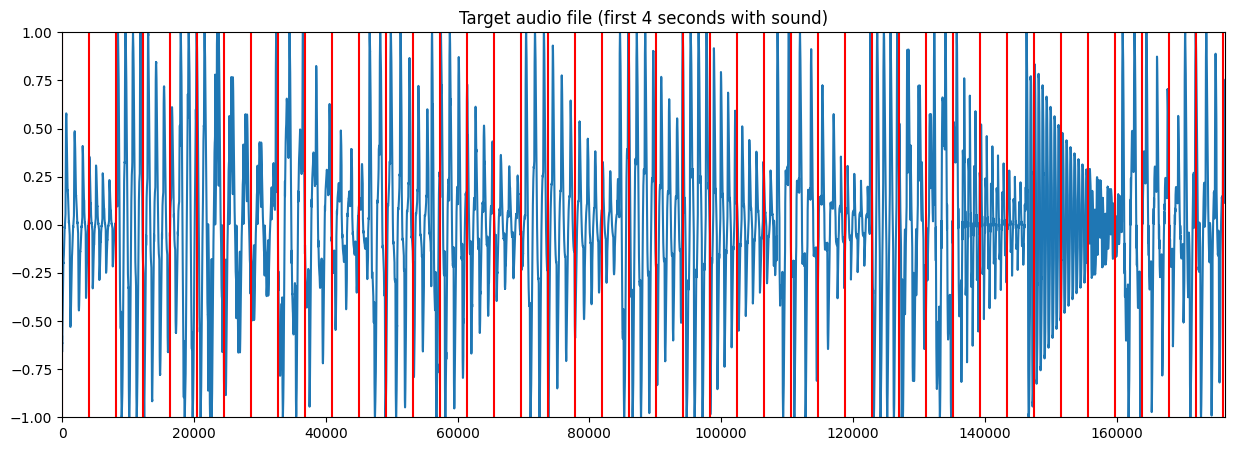

,freesound_id,id,path,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
0,None,None_f0,acid_bass_trimmed.wav,0,4096,1.061935e-02,-833.932251,210.180298,58.224659,54.015327,25.662205,22.992775,10.233212,11.040428,8.585049,11.493971,7.669933,5.849941,4.156281
1,None,None_f1,acid_bass_trimmed.wav,4096,8192,4.824577e-03,-831.254272,236.173645,4.611404,64.654907,10.715244,22.107330,1.352486,7.730843,6.406429,10.888870,6.921608,2.727604,2.640835
2,None,None_f2,acid_bass_trimmed.wav,8192,12288,3.321034e-02,-837.725830,289.316864,29.241879,41.940639,27.807858,16.084572,19.298260,11.857227,12.122654,10.125738,6.875198,6.880096,4.242237
3,None,None_f3,acid_bass_trimmed.wav,12288,16384,2.537591e-02,-836.748779,257.007446,44.816837,58.485874,18.738190,25.308857,13.833050,18.596521,8.985039,5.593533,4.532642,9.497665,5.571926
4,None,None_f4,acid_bass_trimmed.wav,16384,20480,3.052102e-02,-845.674255,286.840881,26.702618,47.508331,16.019024,19.105682,13.210022,11.423878,10.921093,7.714596,9.868446,7.162266,7.712772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,None,None_f130,acid_bass_trimmed.wav,532480,536576,6.869573e-07,-1251.068237,19.455887,19.094414,18.502869,17.696682,16.697449,15.530914,14.227489,12.820171,11.343975,9.834679,8.327732,6.857109
131,None,None_f131,acid_bass_trimmed.wav,536576,540672,3.556720e-07,-1255.853638,12.749039,12.567772,12.270416,11.863232,11.355644,10.758286,10.084362,9.348034,8.564556,7.749611,6.919064,6.088356
132,None,None_f132,acid_bass_trimmed.wav,540672,544768,1.719534e-07,-1259.853027,7.134720,7.077415,6.982941,6.851910,6.686287,6.487473,6.258018,6.000454,5.717632,5.412674,5.088940,4.749939
133,None,None_f133,acid_bass_trimmed.wav,544768,548864,7.139246e-08,-1262.983276,2.724930,2.718559,2.708160,2.693371,2.674690,2.651642,2.624580,2.593502,2.558445,2.519424,2.476513,2.429760


,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
count,135.00000,135.00000,1.350000e+02,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000
mean,274432.00000,278528.00000,1.789713e-02,-854.434631,233.909622,32.710930,44.733013,22.268688,20.004286,13.786098,13.149923,10.173140,9.209039,7.047130,6.050938,4.661982
std,160215.91831,160215.91831,1.025441e-02,146.515060,71.518372,27.109514,13.753201,10.128344,6.409795,5.178955,3.726698,3.854734,3.352062,3.222483,3.217465,3.548242
min,0.00000,4096.00000,4.151205e-08,-1264.586792,0.459015,-29.785389,0.456146,-2.458134,0.450539,-2.389297,0.441994,-1.368488,-1.842094,-1.006405,-4.017654,-6.876369
25%,137216.00000,141312.00000,9.831436e-03,-887.679688,199.402229,17.248257,38.685694,16.609411,16.469206,10.637903,11.113047,8.013538,7.412069,4.911615,4.510975,3.237366
50%,274432.00000,278528.00000,1.928360e-02,-831.254272,256.370941,33.265724,46.548569,20.787006,21.228462,13.781578,13.799866,9.924557,9.263668,6.948498,6.089975,4.518967
75%,411648.00000,415744.00000,2.589705e-02,-785.547638,284.167053,48.454758,53.829384,27.682467,24.480725,17.199413,15.588273,12.253841,11.056977,8.799484,7.597885,6.065403
max,548864.00000,552960.00000,3.816336e-02,-588.302307,327.975647,110.020752,67.749588,46.827187,32.783485,26.487228,23.258831,24.347939,19.357155,19.003044,15.357592,22.277542


In [17]:
TARGET_SOUND_PATH = 'acid_bass_trimmed.wav'
DATAFRAME_TARGET_FILE_FILENAME = 'dataframe_target_acid.csv'

# Analyze the target audio file and store results in a new DataFrame
print('Analyzing target sound {0}'.format(TARGET_SOUND_PATH))
target_analysis = analyze_sound(TARGET_SOUND_PATH, frame_size=4096, sync_with_beats=False)  # Also split audio in chunks of 8192 samples (~185ms)
df_target = pd.DataFrame(target_analysis)
df_target.to_csv(DATAFRAME_TARGET_FILE_FILENAME)
print('Saved target dataframe with {0} entries! {1}'.format(len(df_target), DATAFRAME_TARGET_FILE_FILENAME))

# Plot target audio file waveform and show ticks at the start samples of the chunks
plt.figure(figsize=(15,5))
audio = estd.MonoLoader(filename=TARGET_SOUND_PATH)()
plt.plot(audio)
plt.vlines(df_target['start_sample'].values, -1, 1, color='red')
plt.axis([0, min(len(audio), 44100 * 4), -1, 1])
plt.title('Target audio file (first 4 seconds with sound)')
plt.show()

display(df_target)  # Show data frame contents
df_target.describe()  # Show statistics of numerical fields in data frame